## **Pilot Week3**

**코사인 유사도 분석**  
코사인 유사도를 분석해서 내가 선호하는 음악과 유사한 음악을 추천하기  
이때, 호감도, 재생 횟수에 가중치를 준다!

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

music = pd.read_csv('music.csv')
my_data = pd.read_csv('my_data.csv')

In [37]:
#가중치를 줄 것임 -> 호감도와 재생 횟수
#가중치 = 호감도 * 재생 횟수
#재생 횟수의 차이가 크기 때문에 스케일링 진행
#재생 횟수가 집계 되지 않은 음악도 있기 때문에 1을 더해서 가중치가 0이되지 않도록 할 것임
my_data['Count_scaled'] = np.log1p(my_data['Count'])
my_data['Weight'] = my_data['Score'] * (1 + my_data['Count_scaled'])

In [38]:
my_data.head(10)

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Duration_ms,Views,Likes,Comments,official_video,Stream,Score,Count,Count_scaled,Weight
0,Bruno Mars,When I Was Your Man,Unorthodox Jukebox,album,0.612,0.280,0.0,-8.648,0.0434,0.93200,...,213827.0,1.237507e+09,6771190.0,193121.0,True,1.439567e+09,5,0,0.000000,5.000000
1,Miley Cyrus,Flowers,Flowers,single,0.707,0.681,0.0,-4.325,0.0668,0.06320,...,200455.0,1.545193e+08,4625162.0,117998.0,True,2.838849e+08,5,0,0.000000,5.000000
2,Maroon 5,Memories,JORDI (Deluxe),album,0.775,0.327,11.0,-7.241,0.0557,0.84100,...,189486.0,9.018294e+08,9050321.0,265339.0,True,1.651773e+09,5,278,5.631212,33.156059
3,Mariah Carey,All I Want for Christmas Is You,Merry Christmas,album,0.336,0.627,7.0,-7.463,0.0384,0.16400,...,241107.0,7.532190e+08,3874002.0,249083.0,True,1.437978e+09,5,157,5.062595,30.312975
4,The Weeknd,Blinding Lights,After Hours,album,0.514,0.730,1.0,-5.934,0.0598,0.00146,...,200040.0,6.741645e+08,8817927.0,282589.0,True,3.386520e+09,5,96,4.574711,27.873555
5,Christina Perri,A Thousand Years,A Thousand Years,single,0.421,0.407,10.0,-7.445,0.0267,0.30900,...,285120.0,2.213836e+09,13816579.0,482413.0,True,1.261326e+09,5,0,0.000000,5.000000
6,Will Smith,Arabian Nights (2019),Aladdin (Original Motion Picture Soundtrack),compilation,0.445,0.532,8.0,-8.018,0.0405,0.25400,...,193096.0,3.846088e+07,490390.0,17000.0,True,7.859856e+07,5,45,3.828641,24.143207
7,Charlie Puth,See You Again (feat. Charlie Puth),See You Again (feat. Charlie Puth),single,0.689,0.481,10.0,-7.503,0.0815,0.36900,...,229526.0,5.773798e+09,40147674.0,2127346.0,True,1.521255e+09,5,144,4.976734,29.883669
8,Disney,Gotta Go My Own Way,High School Musical 2 (Original Soundtrack),compilation,0.555,0.692,9.0,-4.767,0.0277,0.08640,...,222360.0,3.122220e+07,322458.0,11634.0,True,1.470210e+08,5,45,3.828641,24.143207
9,Logic,1-800-273-8255,Everybody,album,0.620,0.574,5.0,-7.788,0.0479,0.56900,...,250173.0,4.377071e+08,5446669.0,391614.0,True,1.212603e+09,5,265,5.583496,32.917482


In [39]:
#처리하지 못한 결측치를 제거하겠습니다!
music = music.dropna(subset=features)
my_data = my_data.dropna(subset=features)

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

#특성들을 스케일링 해줍니다!

#콘텐츠 기반 추천을 하기 위해서 메타 데이터, 범주형, 인기 지표, 사용자 지표를 제외한 특성을 고르겠습니다.
features = [
'Danceability','Energy','Loudness','Speechiness',
'Acousticness','Instrumentalness','Liveness',
'Valence','Tempo','Duration_ms'
]

#music 데이터를 스케일링 해줍니다
scaler = StandardScaler()

music_scaled = scaler.fit_transform(music[features])

#데이터 프레임으로 변환
music_scaled = pd.DataFrame(
    music_scaled,
    columns=features,
    index=music.index
)

#my_data도 스케일링
my_scaled = scaler.transform(my_data[features])

my_scaled = pd.DataFrame(
    my_scaled,
    columns=features,
    index=my_data.index
)

#사용자 취향 벡터 생성
X = my_scaled.values
w = my_data['Weight'].values.reshape(-1,1)

user_profile = (X * w).sum(axis=0) / w.sum()

#전체 음악과 코사인 유사도 계산
similarity = cosine_similarity(
    [user_profile],
    music_scaled
)

#추천 결과 생성
music['similarity'] = similarity[0]

recommend = music.sort_values(
    'similarity',
    ascending=False
)

#이미 들었던 음악은 제거하고
recommend = recommend[
    ~recommend['Track'].isin(my_data['Track'])
]

#추천하는 음악 10개 출력
recommend.head(10)[['Track','Artist','similarity']]

,Track,Artist,similarity
15805,Bad At Love,Halsey,0.922660
13416,Give Your Heart a Break,Demi Lovato,0.921801
18148,Little Bit of Love,Tom Grennan,0.897700
6527,All Stars,Martin Solveig,0.894325
13852,Bones,Imagine Dragons,0.890686
14656,Follow Me,Rita Ora,0.889972
16681,Follow Me,Sam Feldt,0.889972
18062,Always Be There,Jonas Blue,0.884721
16684,Call On Me (feat. Georgia Ku),Sam Feldt,0.882170
17105,Just A Stranger (feat. Steve Lacy),Kali Uchis,0.882027


**호감도 예측 회귀 모델**

In [50]:
#라이브러리 임포트
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [52]:
#feature 선택과 처리하지 못한 결측치 전처리
features = [
'Danceability','Energy','Loudness','Speechiness',
'Acousticness','Instrumentalness','Liveness',
'Valence','Tempo'
]

music[features] = music[features].fillna(music[features].mean())
my_data[features] = my_data[features].fillna(music[features].mean())

#feature 스케일링
scaler = StandardScaler()

music_scaled = scaler.fit_transform(music[features])
my_scaled = scaler.transform(my_data[features])

In [54]:
#학습 할 데이터 셋을 만들어 주겠습니다
#스케일링한 음악 특성이 독립변수, 호감도인 Score가 종속변수가 될 것입니다
X = my_scaled
y = my_data['Score']

#재생 횟수를 가중치로 주겠습니다
sample_weight = 1 + np.log1p(my_data['Count'])

In [56]:
#train test split해줍니다! 가중치도 함께!
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X,y,sample_weight,test_size=0.2)

In [58]:
#회귀 모델 만들기
#가장 기본적인 모델로 RandomForest를 사용했습니다
model = RandomForestRegressor(n_estimators=200)

model.fit(X_train,y_train,sample_weight=w_train)

#예측
y_pred = model.predict(X_test)

In [60]:
#이제 여러 지표로 평가해보겠습니다!

#mae
mae = mean_absolute_error(y_test, y_pred)

#rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#r^2
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.142736247265669
RMSE: 1.3423265332065675
R2: 0.03448965861708042


In [62]:
#음악을 추천해보겠습니다!
pred = model.predict(music_scaled)

music['pred_score'] = pred

#이미 들은 음악을 제거하고
recommend = music[
    ~music['Track'].isin(my_data['Track'])
]

#10개를 추천해보겠습니다
recommend = recommend.sort_values(
    'pred_score',
    ascending=False
)

print("추천 음악")
print(recommend.head(10)[['Track','Artist','pred_score']])

추천 음악
                                       Track          Artist  pred_score
17940                            Better Days  Dermot Kennedy       4.455
15395                            Decrescendo         Lomepal       4.270
19138                                Useless     Omar Apollo       4.260
16872       Wishful Drinking (with Sam Hunt)        Sam Hunt       4.255
3058   Aunque no sea conmigo - 2018 Remaster         Bunbury       4.230
13587                              Tu Hi Hai    Amit Trivedi       4.180
13080         I Need A Girl (Feat. G-DRAGON)         TAEYANG       4.180
12682                                  Candy    Paolo Nutini       4.170
18667                                  GANAS    Young Cister       4.160
20264                                  Dengo      João Gomes       4.125


In [68]:
#다른 모델을 사용해서 회귀모델을 만들어보겠습니다!
#성능을 좀 더 키우기 위해 XGBoost를 사용해보겠습니다
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(objective='reg:squarederror')

#Random Search로 하이퍼파라미터도 조정해보겠습니다
param_dist = {

'n_estimators': [100, 200, 300, 500],

'max_depth': [3,4,5,6,7,8],

'learning_rate': [0.01, 0.05, 0.1, 0.2],

'subsample': [0.6, 0.8, 1.0],

'colsample_bytree': [0.6, 0.8, 1.0],

'min_child_weight': [1,3,5]

}

#랜덤 서치 CV를 해줍니다
random_search = RandomizedSearchCV(

    estimator=xgb,
    param_distributions=param_dist,

    n_iter=30,
    cv=5,

    scoring='neg_mean_absolute_error',

    n_jobs=-1,
    random_state=42
)

#모델 학습
random_search.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

#최적의 모델을 만들어보겠습니다
best_model = random_search.best_estimator_

print("Best Params:")
print(random_search.best_params_)

Best Params:
{'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [70]:
#예측
y_pred = best_model.predict(X_test)

#모델 평가
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.1166094050687903
RMSE: 1.356094675765288
R2: 0.014581748283695961


In [72]:
#음악 추천

#전체 음악 호감도
pred = best_model.predict(music_scaled)

music['pred_score'] = pred

#이미 들은 음악 제거
recommend = music[
    ~music['Track'].isin(my_data['Track'])
]

#음악 추천!
recommend = recommend.sort_values(
    'pred_score',
    ascending=False
)

print("추천 음악")
print(recommend.head(10)[['Track','Artist','pred_score']])

추천 음악
                                        Track              Artist  pred_score
8436        Sharp Dressed Man - 2008 Remaster              ZZ Top    5.542819
19935                                  Insane       Gurinder Gill    5.541662
19778                                  Insane          AP Dhillon    5.541662
11911             Good Old Days (feat. Kesha)          Macklemore    5.474648
10347                                   Mitwa  Shafqat Amanat Ali    5.471364
12146                                   Mitwa   Caralisa Monteiro    5.471364
1435                                    Mitwa   Shankar Mahadevan    5.471364
3434                                    Mitwa  Shankar-Ehsaan-Loy    5.471364
637    Sunday Bloody Sunday - Remastered 2008                  U2    5.398283
6795                                     1982        Randy Travis    5.380778


2개의 모델을 사용해봤지만 결론적으로는 둘 다 성능이 별로 좋지 않습니다... 
모델이 거의 학습을 못한 상태에 가깝다고 볼 수 있는데요
MAE 결과로 예측한 점수가 실제 점수와 평균적으로 약 1.12점 차이가 난다고 볼 수 있습니다
그리고 R^2값을 봤을 때 모델이 Score 변동의 1.4%만 설명합니다

이렇게 성능이 좋지 않은 이유는 

1. 데이터가 너무 적음    
2. Score분포가 작음(0~5)  
3. feature가 취향을 설명 못함

이 데이터로는 취향을 맞추기에는 너무 어려운 것 같습니다..

더 좋은 추천을 할 수 있도록 코사인 유사도와 회귀 모델을 결합해보겠습니다!

In [106]:
#특징 뽑기
features = [
'Danceability','Energy','Loudness','Speechiness',
'Acousticness','Instrumentalness','Liveness',
'Valence','Tempo','Duration_ms'
]

#데이터 스케일링
scaler = StandardScaler()

music_scaled = scaler.fit_transform(music[features])

music_scaled = pd.DataFrame(
    music_scaled,
    columns=features,
    index=music.index
)

#내가 좋아하는 음악 선택
liked = my_data.sort_values(
    'Score',
    ascending=False
).head(10)

#좋아하는 음악 스케일링
liked_features = scaler.transform(liked[features])

#전체 음악과 유사도 계산
sim = cosine_similarity(
    music_scaled,
    liked_features
)

#평균 유사도 생성
music['user_similarity'] = sim.mean(axis=1)

#my_data에 유사도 추가
my_features_model = my_data[features].copy()

my_features_model['user_similarity'] = music.loc[
    my_data.index,
    'user_similarity'
]

#모델 feature 선택
features_model = features + ['user_similarity']

In [108]:
#데이터 셋 만들기
X = my_features_model[features_model]
y = my_data['Score']

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#XGBoost
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

#예측
y_pred = model.predict(X_test)

In [110]:
#평가
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.18235739773395
RMSE: 1.3522889488854435
R2: 0.20726487854611808


R^2값이 꽤 증가해서
모델의 20%를 설명할 수 있게 되었습니다!

In [116]:
#음악 추천
music_features_model = music[features_model]

pred_score = model.predict(music_features_model)

music['pred_score'] = pred_score

recommend = music.sort_values(
    'pred_score',
    ascending=False
)

recommend = recommend[
    ~recommend['Track'].isin(my_data['Track'])
]

recommend[['Track','Artist','pred_score']].head(10)

,Track,Artist,pred_score
5456,Morning Show,Iggy Pop,5.039740
9146,Teardrop,Massive Attack,4.995412
16445,The Spectre,Alan Walker,4.756647
2058,One of Those Days (feat. Eric Clapton),Ozzy Osbourne,4.742147
11769,Abres Camino (Way Maker),Marcela Gandara,4.734095
10405,Take Me Away,Plain White T's,4.732150
10023,Você Não Sabe Voltar - Ao Vivo,Pixote,4.723566
2576,Puente,Gustavo Cerati,4.713734
8170,Arrullo De Estrellas,Zoé,4.707148
14330,Kids - The Chainsmokers Remix,Mikky Ekko,4.655235


성능이 좋아지긴 했지만 아직까지는 데이터가 작아 한계가 있는 듯 합니다.  
더 좋은 추천을 할 수 있는 방법을 찾아야 할 것 같습니다 

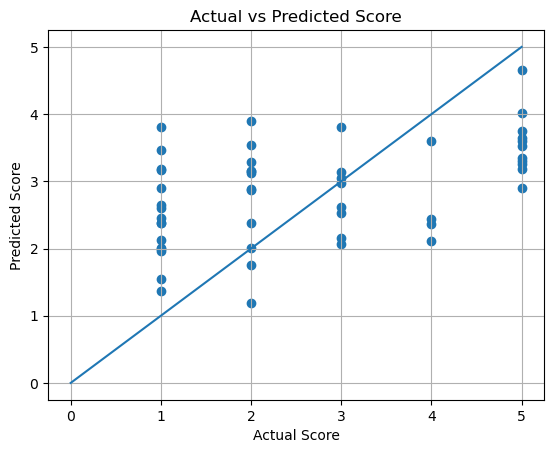

In [120]:
#시각화
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Score")

plt.plot([0,5],[0,5])  # 완벽한 예측 기준선

plt.grid()
plt.show()

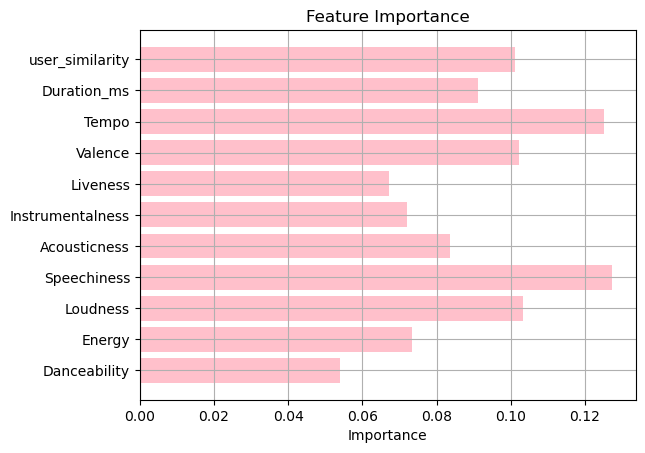

In [124]:
importance = model.feature_importances_

plt.figure()

plt.barh(features_model, importance, color='pink')

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.grid()

plt.show()